# Final Advanced Terrain Corrections for Gravity
## Molly Bilhartz, Samantha Lopez, Tessa Murphy

This notebook and corresponding onyx_clean_lidar_terrain_correction.py file are accurately testing and comuting advanced terrain corrections on our gravity measurments using DEM data. 

In [1]:
from pathlib import Path
import sys
import importlib
import matplotlib.pyplot as plt

PROJECT = Path.cwd().parents[1]

PY_DIR = PROJECT / "notebooks" / "PY files"
GRAVITY_DIR = PROJECT / "data" / "gravity"
LIDAR_DIR = PROJECT / "data" / "LiDAR"

sys.path.append(str(PY_DIR))

import onyx_clean_lidar_terrain_correction as tc
importlib.reload(tc)

PROFILE_CSV = GRAVITY_DIR / "raw_data/gps_data/grp2n1onyx_profile.csv"

LIDAR_TILE_DIR = LIDAR_DIR / "LiDAR_2026-06-05T19_40_33.076Z"
DEM_TILES = sorted(LIDAR_TILE_DIR.glob("*.tif"))

OUT_CSV = GRAVITY_DIR / "Onyx_Profile_Harmonica_LiDAR_Corrected.csv"
OUT_DEM = LIDAR_DIR / "Onyx_Profile_Merged_DEM_UTM13N.tif"

# out, topo = tc.run_lidar_terrain_correction(
#     profile_csv=PROFILE_CSV,
#     dem_tiles=DEM_TILES,
#     out_csv=OUT_CSV,
#     out_dem=OUT_DEM,
#     dst_crs="EPSG:26913",
#     dem_z_factor=0.30480060960121924,
#     model_spacing_m=5.0,
#     pad_m=500.0,
#     density_kg_m3=2670.0,
#     upward_offset_m=0.25,
#     reference_mode="mean_station_elevation",
# )

# out.head()

In [2]:
import importlib
importlib.reload(tc)

out, topo = tc.run_lidar_terrain_correction(
    profile_csv=PROFILE_CSV,
    dem_tiles=DEM_TILES,
    out_csv=OUT_CSV,
    out_dem=OUT_DEM,
    dst_crs="EPSG:26913",
    dem_z_factor=0.30480060960121924,
    model_spacing_m=5.0,
    pad_m=500.0,
    density_kg_m3=2670.0,
    upward_offset_m=0.25,
    reference_mode="mean_station_elevation",
)


NaN count before dropping:
station     0
lat         4
lon         4
elev_m      4
grav_rel    0
FAC         4
dtype: int64

Dropping rows with missing required values:
    station  lat  lon  elev_m  grav_rel  FAC
19     16.5  NaN  NaN     NaN    0.3978  NaN
21     17.5  NaN  NaN     NaN    0.4081  NaN
31     26.2  NaN  NaN     NaN    0.5511  NaN
35     29.2  NaN  NaN     NaN    0.6219  NaN

Rows retained after dropping NaNs: 32

Station easting range:
344409.69393728493 344418.17066217173

Station northing range:
4482508.4509999165 4482530.829019284

Cropped DEM elevation range, meters:
2042.5241002825758 2212.1815071755145

Saved corrected gravity CSV:
/Users/tessamurphy/work/classes/GPGN486/Geophysical-Characterization-of-the-Historic-Onyx-Mine-in-Steamboat-Springs-CO.-/data/gravity/Onyx_Profile_Harmonica_LiDAR_Corrected.csv

Saved merged DEM:
/Users/tessamurphy/work/classes/GPGN486/Geophysical-Characterization-of-the-Historic-Onyx-Mine-in-Steamboat-Springs-CO.-/data/LiDAR/Onyx_Pro

In [3]:
out.columns.tolist()

['station',
 'lat',
 'lon',
 'elev_m',
 'grav_mean',
 'grav_dc',
 'grav_rel',
 'FAC',
 'FAA',
 'instrument',
 'n',
 'grav_std',
 'datetime_mid',
 'easting',
 'northing',
 'station_m',
 'elevation_m',
 'gravity_tied_mgal',
 'free_air_correction_mgal',
 'reference_elevation_m',
 'obs_height_used_m',
 'harmonica_gz_mgal',
 'gravity_free_air_only_mgal',
 'harmonica_gz_relative_mgal',
 'corrected_add_rel_mgal',
 'corrected_subtract_rel_mgal',
 'gravity_harmonica_lidar_corrected_mgal']

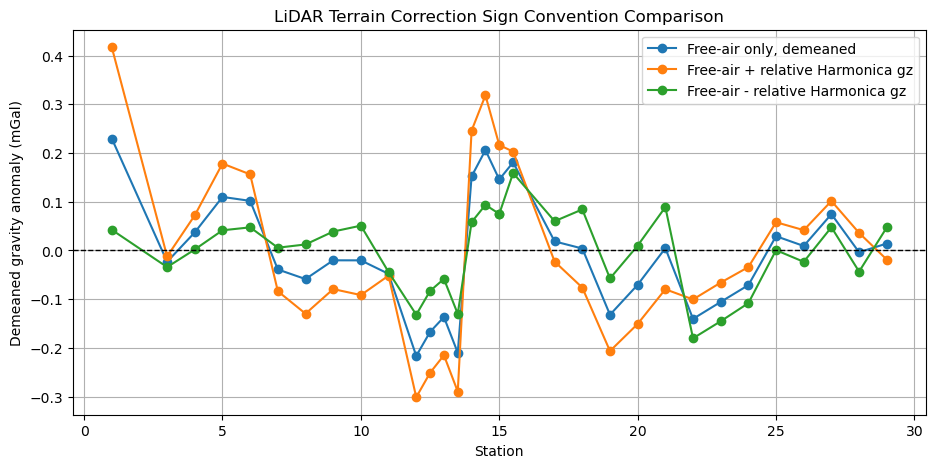

In [3]:
plt.figure(figsize=(11, 5))

plt.plot(
    out["station"],
    out["gravity_free_air_only_mgal"] - out["gravity_free_air_only_mgal"].mean(),
    marker="o",
    label="Free-air only, demeaned",
)

plt.plot(
    out["station"],
    out["corrected_add_rel_mgal"] - out["corrected_add_rel_mgal"].mean(),
    marker="o",
    label="Free-air + relative Harmonica gz",
)

plt.plot(
    out["station"],
    out["corrected_subtract_rel_mgal"] - out["corrected_subtract_rel_mgal"].mean(),
    marker="o",
    label="Free-air - relative Harmonica gz",
)

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station")
plt.ylabel("Demeaned gravity anomaly (mGal)")
plt.title("LiDAR Terrain Correction Sign Convention Comparison")
plt.grid(True)
plt.legend()
plt.show()

We tested both possible Harmonica sign conventions. Adding the relative modeled terrain field amplified the anomaly, while subtracting it reduced the terrain-correlated structure. Therefore, the final LiDAR terrain correction used the subtract-relative convention.

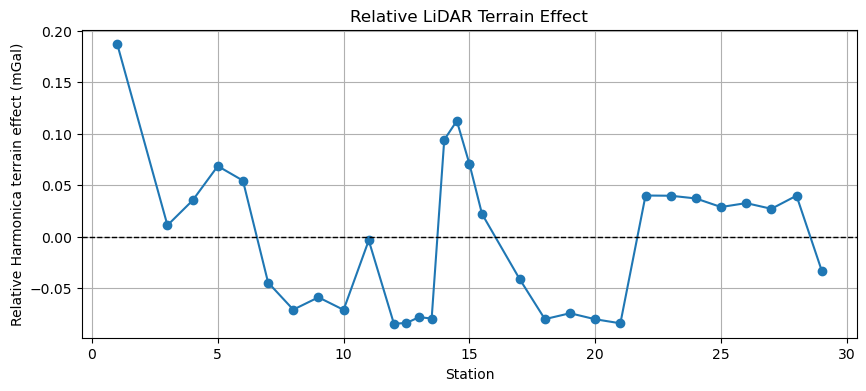

In [5]:
plt.figure(figsize=(10, 4))

plt.plot(
    out["station"],
    out["harmonica_gz_relative_mgal"],
    marker="o",
)

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station")
plt.ylabel("Relative Harmonica terrain effect (mGal)")
plt.title("Relative LiDAR Terrain Effect")
plt.grid(True)
plt.show()

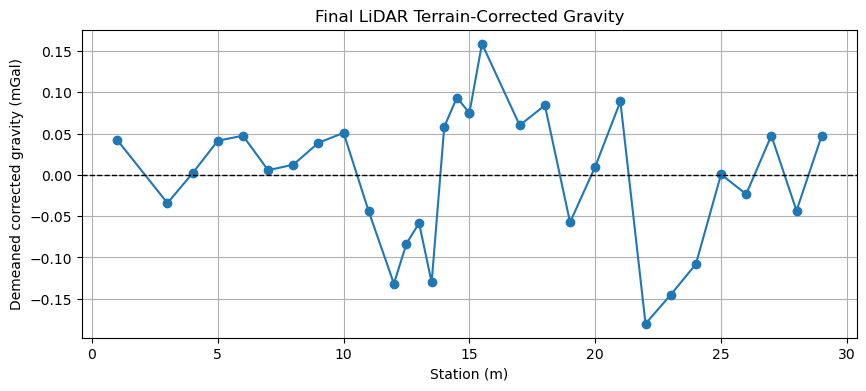

In [7]:
plt.figure(figsize=(10, 4))

plt.plot(
    out["station"],
    out["gravity_harmonica_lidar_corrected_mgal"]
    - out["gravity_harmonica_lidar_corrected_mgal"].mean(),
    marker="o",
)

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station (m)")
plt.ylabel("Demeaned corrected gravity (mGal)")
plt.title("Final LiDAR Terrain-Corrected Gravity")
plt.grid(True)
plt.show()

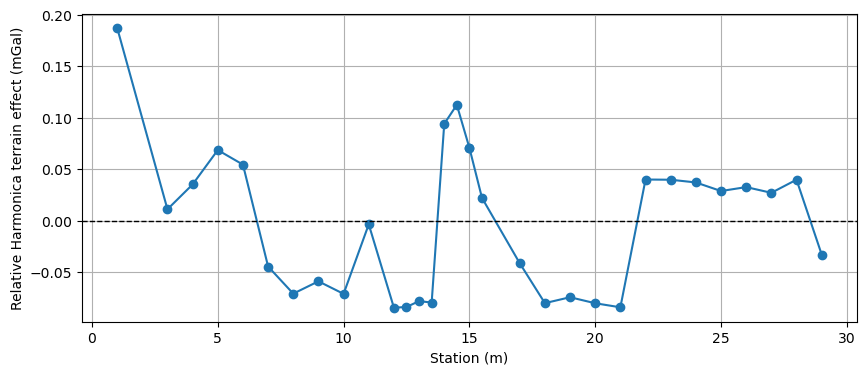

In [9]:
plt.figure(figsize=(10, 4))

plt.plot(
    out["station"],
    out["harmonica_gz_relative_mgal"],
    marker="o",
)

plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.xlabel("Station (m)")
plt.ylabel("Relative Harmonica terrain effect (mGal)")
#plt.title("Relative LiDAR Terrain Effect")
plt.grid(True)

plt.savefig(
    "../../figures/Final_figures/Relative_LiDAR_Terrain_Effect.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Overlaying expectd tunnel gravity anomalies withour final corrected gravity

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Horizontal tunnel gravity model
# -----------------------------
G = 6.67430e-11
FT_TO_M = 0.3048
tunnel_length = 200 * FT_TO_M   # 200 ft = 60.96 m

def finite_horizontal_square_tunnel_gravity(
    x_obs,
    x0,
    side_length,
    depth_center,
    density_contrast_gcc=-2.35,
    length=tunnel_length,
    n_y=400,
):
    density_contrast = density_contrast_gcc * 1000  # kg/m^3
    area = side_length**2

    y = np.linspace(-length / 2, length / 2, n_y)
    dy = y[1] - y[0]

    gz = np.zeros_like(x_obs, dtype=float)

    for yi in y:
        dx = x_obs - x0
        r2 = dx**2 + yi**2 + depth_center**2
        r = np.sqrt(r2)

        dV = area * dy
        dm = density_contrast * dV

        gz += G * dm * depth_center / r**3

    return gz * 1e5  # mGal

In [11]:
# -----------------------------
# New observed residual anomaly
# -----------------------------
x = out["station"].to_numpy(dtype=float)
g = out["gravity_harmonica_lidar_corrected_mgal"].to_numpy(dtype=float)

# Demean to make relative residual anomaly
g_resid = g - np.nanmean(g)

# Optional: remove linear regional trend instead of just demeaning
# coeff = np.polyfit(x, g, 1)
# trend = np.polyval(coeff, x)
# g_resid = g - trend

out["final_lidar_residual_mgal"] = g_resid

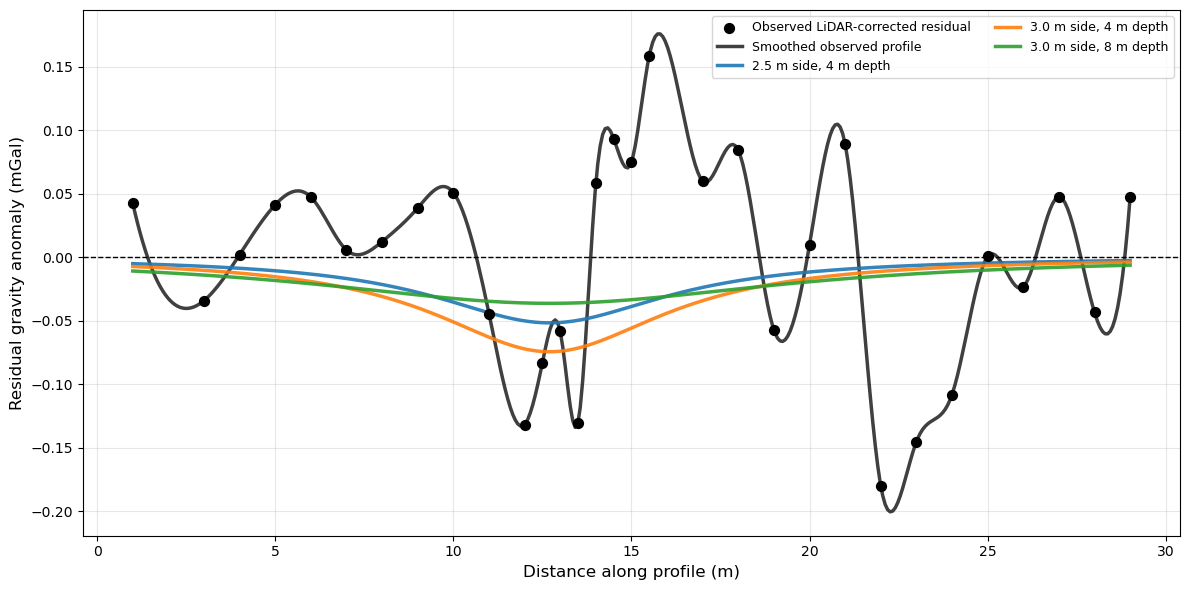

In [18]:
# -----------------------------
# Cleaner overlay expected tunnel anomalies at 12–13 m only
# -----------------------------
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.figure(figsize=(12, 6))

# Average duplicate stations first
profile = (
    pd.DataFrame({"x": x, "g": g_resid})
    .dropna()
    .groupby("x", as_index=False)
    .mean()
    .sort_values("x")
)

x_plot = profile["x"].to_numpy()
g_plot = profile["g"].to_numpy()

# Smooth observed profile
x_smooth = np.linspace(x_plot.min(), x_plot.max(), 400)

try:
    spline = make_interp_spline(x_plot, g_plot, k=3)
    g_smooth = spline(x_smooth)
except Exception:
    g_smooth = np.interp(x_smooth, x_plot, g_plot)

# Plot observed data
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.scatter(
    x_plot,
    g_plot,
    color="black",
    s=50,
    zorder=5,
    label="Observed LiDAR-corrected residual",
)

plt.plot(
    x_smooth,
    g_smooth,
    color="black",
    linewidth=2.5,
    alpha=0.75,
    label="Smoothed observed profile",
)

# --------------------------------------------------
# Tunnel models ONLY centered on the 12–13 m anomaly
# --------------------------------------------------

x0_model = 12.7   # center of first negative anomaly

model_cases = [
    (2.5, 4),
    (3.0, 4),
    (3.0, 8),
]

for side, depth in model_cases:
    g_test = finite_horizontal_square_tunnel_gravity(
        x_obs=x_smooth,
        x0=x0_model,
        side_length=side,
        depth_center=depth,
        density_contrast_gcc=-2.5,
    )

    plt.plot(
        x_smooth,
        g_test,
        linewidth=2.5,
        alpha=0.9,
        label=f"{side} m side, {depth} m depth",
    )

plt.xlabel("Distance along profile (m)", fontsize=12)
plt.ylabel("Residual gravity anomaly (mGal)", fontsize=12)
# plt.title(
#     "Observed LiDAR-Corrected Residual with Expected Tunnel Anomaly at 12–13 m",
#     fontsize=14,
# )

plt.grid(True, alpha=0.3)
plt.legend(fontsize=9, ncol=2, frameon=True)
plt.tight_layout()

plt.savefig(
    "../../figures/Final_figures/LiDAR_Residual_W_Expected_Anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()